Summary Statistics: 
         Unnamed: 0                 model_name brand    processor_name  \
count   1014.000000                       1014  1014              1014   
unique          NaN                        924    22               123   
top             NaN  Dell Latitude 3420 Laptop  Asus  12th Gen Core i5   
freq            NaN                          7   220               153   
mean     510.264300                        NaN   NaN               NaN   
std      293.245029                        NaN   NaN               NaN   
min        0.000000                        NaN   NaN               NaN   
25%      257.250000                        NaN   NaN               NaN   
50%      510.500000                        NaN   NaN               NaN   
75%      763.750000                        NaN   NaN               NaN   
max     1017.000000                        NaN   NaN               NaN   

            ram(GB)      ssd(GB)  Hard Disk(GB) Operating System  \
count   1014.000000  1

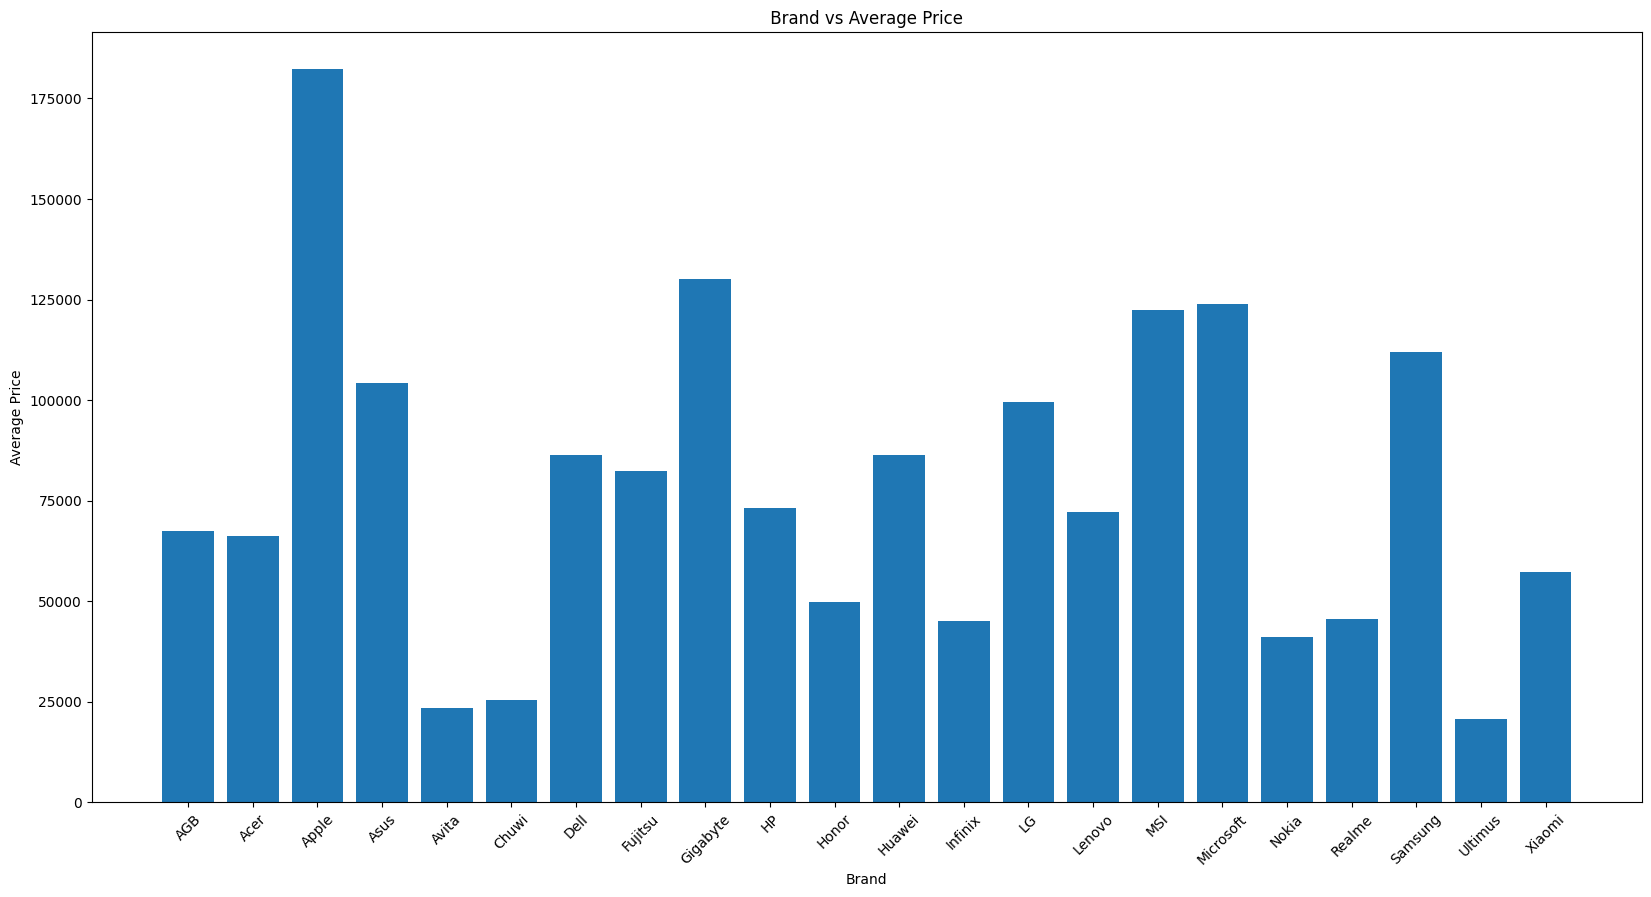

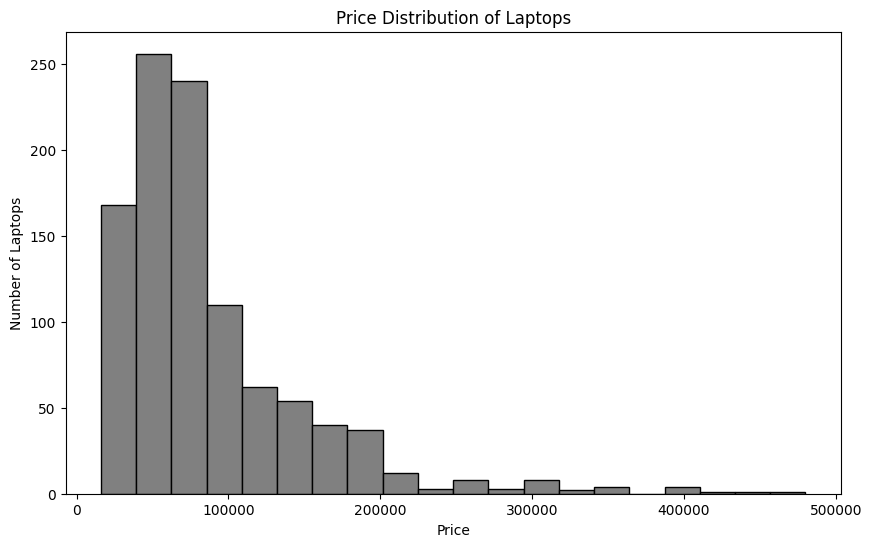

<Figure size 1600x800 with 0 Axes>

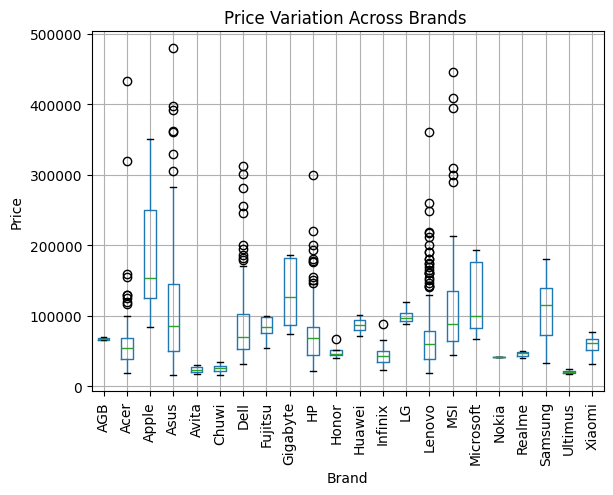

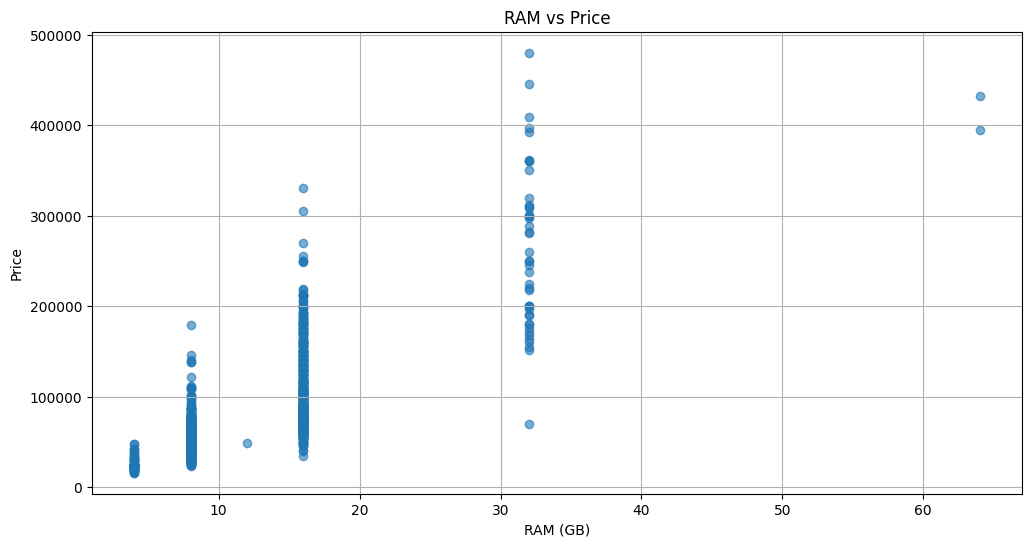

<Figure size 1200x600 with 0 Axes>

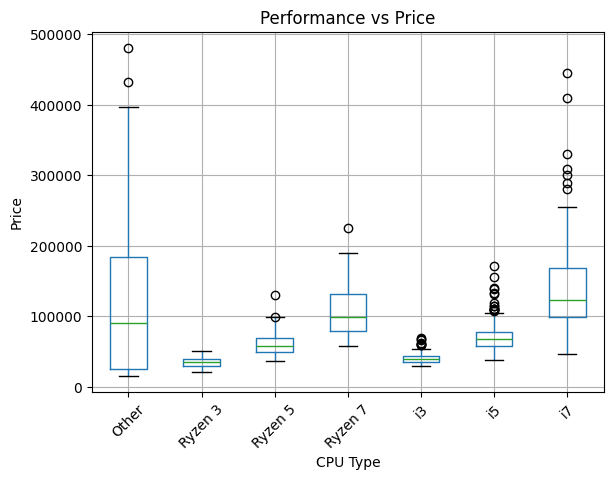

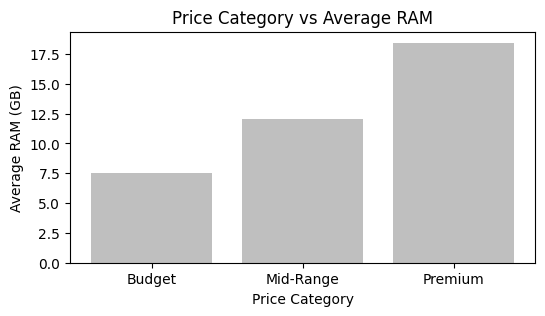

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("laptop.csv")

print("Summary Statistics: ")
print(df.describe(include = 'all'))

def categorize_price(price_val):
    if price_val < 50000:
        return 'Budget'
    elif price_val < 100000:
        return "Mid-Range"
    else:
        return "Premium"

df['price_type'] = df['price'].apply(categorize_price)

print("Added column to filter price into categories: ")
print(df)

def cpu_category(processor_name):
    if 'i3' in processor_name:
        return 'i3'
    elif 'i5' in processor_name:
        return 'i5'
    elif 'i7' in processor_name:
        return 'i7'
    elif 'Ryzen 3' in processor_name:
        return 'Ryzen 3'
    elif 'Ryzen 5' in processor_name:
        return 'Ryzen 5'
    elif 'Ryzen 7' in processor_name:
        return 'Ryzen 7'
    else:
        return 'Other'

df['cpu_type'] = df['processor_name'].apply(cpu_category)

print("Added column to simplify cpu names: ")
print(df)

def storage_type(row):
    if row['ssd(GB)'] > 0 and row['Hard Disk(GB)'] > 0:
        return 'Hybrid'
    elif row['ssd(GB)'] > 0:
        return 'SSD'
    else:
        return 'HDD'

df['storage_type'] = df.apply(storage_type, axis=1)

print("Added column for Classification of storage: ")
print(df)

print("Grouping: Brand and Average Price")
print(df.groupby('brand')['price'].mean())

print("Grouping: Memory Size and Price")
print(df.groupby('ram(GB)')['price'].mean())

print("Grouping: Average ram differs")
print(df.groupby('price_type')['ram(GB)'].mean())

brand_avg_price = df.groupby('brand')['price'].mean()
plt.figure(figsize=(20,10))
plt.bar(brand_avg_price.index, brand_avg_price.values)
plt.title(" Brand vs Average Price ")
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=20, edgecolor = 'black', color='grey')
plt.title("Price Distribution of Laptops")
plt.xlabel("Price")
plt.ylabel("Number of Laptops")
plt.show()

plt.figure(figsize=(16,8))
df.boxplot(column='price', by='brand')
plt.title("Price Variation Across Brands ")
plt.suptitle("")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,6))
plt.scatter(df['ram(GB)'], df['price'], alpha=0.6)
plt.title("RAM vs Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
df.boxplot(column='price', by='cpu_type')
plt.title("Performance vs Price")
plt.suptitle("")
plt.xlabel("CPU Type")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

avg_ram = df.groupby('price_type')['ram(GB)'].mean()
plt.figure(figsize=(6,3))
plt.bar(avg_ram.index, avg_ram.values, alpha=0.5, color="grey")
plt.title("Price Category vs Average RAM")
plt.xlabel("Price Category")
plt.ylabel("Average RAM (GB)")
plt.show()

